# Description

This notebook prepares the data for the NBS analysis between the two extreme sets of scans.

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import os.path as osp
import os
from tqdm import tqdm
from shutil import rmtree
import seaborn as sns
import matplotlib.pyplot as plt
from utils.basics import RESOURCES_NBS_DIR, ATLASES_DIR, RESOURCES_SNYCQ_DIR, DATA_DIR
from utils.basics import FB_400ROI_ATLAS_NAME as ATLAS_NAME
from utils.basics import FB_400ROI_BRAINNET_NODES_PATH as BRAINNET_NODES_PATH
import panel as pn
from matplotlib import colors
from sklearn.preprocessing import OneHotEncoder
from sfim_lib.io.afni import load_netcc
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# 1. Load Information about scans

In [2]:
emb_plus  = pd.read_csv(osp.join(RESOURCES_SNYCQ_DIR, 'SNYCQ_tsne_embeddings_plus.csv'), index_col=[0,1])
emb_plus.drop(['TSNE1','TSNE2','TSNE3'],axis=1,inplace=True)
emb_plus.head(3)

Positive  Negative  Future  Past  \
Subject    Run                                                           
sub-010014 post-ses-02-run-01-acq-AP      80.0      15.0    50.0  55.0   
           post-ses-02-run-01-acq-PA      60.0      10.0    75.0  70.0   
           post-ses-02-run-02-acq-AP      55.0      60.0    65.0  40.0   

                                      Myself  People  Surroundings  Images  \
Subject    Run                                                               
sub-010014 post-ses-02-run-01-acq-AP    30.0    65.0          55.0    95.0   
           post-ses-02-run-01-acq-PA    65.0    65.0          80.0    95.0   
           post-ses-02-run-02-acq-AP    50.0    60.0          65.0    75.0   

                                      Words  Specific  Intrusive  Set Label  \
Subject    Run                                                                
sub-010014 post-ses-02-run-01-acq-AP   90.0      25.0       30.0      Set B   
           post-ses-02-run-01-acq-PA   85.0      25.0       55.0      Set B   
           post-ses-02-run-02-acq-AP   85.0      30.0       60.0  Ambiguous   

                                      Group Probability  
Subject    Run                                           
sub-010014 post-ses-02-run-01-acq-AP           0.925632  
           post-ses-02-run-01-acq-PA           0.939779  
           post-ses-02-run-02-acq-AP           0.574845

In [3]:
scans_in_set_A     = emb_plus[emb_plus['Set Label']=='Set A'].index
scans_in_set_B     = emb_plus[emb_plus['Set Label']=='Set B'].index
SELECTED_SCANS     = emb_plus[emb_plus['Set Label']!='Ambiguous'].index#scans_in_set_A.append(scans_in_set_B)
FINAL_N_scans      = SELECTED_SCANS.shape[0]
FINAL_N_sbjs       = SELECTED_SCANS.get_level_values('Subject').unique().shape[0]

# 2. Load the FC matrices for selected scans in an Xarray

This xarray will be indexed by ```<SBJ>.<SCAN>``` on the scan dimension, and ROI names in the other two dimensions

In [4]:
ATLASINFO_PATH = osp.join(ATLASES_DIR,ATLAS_NAME,'{ATLAS_NAME}.roi_info.csv'.format(ATLAS_NAME=ATLAS_NAME))
roi_info       = pd.read_csv(ATLASINFO_PATH)
Nrois          = roi_info.shape[0]
print("++ INFO: Selected Atlas = %s" % ATLAS_NAME)
print("++ INFO: Number of ROIs = %d" % Nrois)

++ INFO: Selected Atlas = Schaefer2018_400Parcels_7Networks_AAL2
++ INFO: Number of ROIs = 380


In [5]:
%%time
# Create Empty Numpy Array where to hold all FC matrices. At the end we will move this into an Xarray
# ===================================================================================================
sfc_Z_arr      = np.empty((FINAL_N_scans,Nrois,Nrois)) * np.nan
print('++ INFO: Shape of final Xarray: %s' % str(sfc_Z_arr.shape))
i              = 0  # Index to move through the scan dimension numerically
xr_coords_scan = [] # List of scan IDs to later use as the coordinates for the scan dimension

# For each scan in a given cluster
# ================================
for sbj,run in tqdm(SELECTED_SCANS):
    # Load FC matrix from disk
    # ========================
    xr_coords_scan.append('.'.join([sbj,run])) 
    _,_,sesID,_,runID,_,acqID = run.split('-')
    sfc_path = osp.join(DATA_DIR,'PrcsData',sbj,'preprocessed','func','pb06_staticFC','{acqID}_run-{runID}.{ATLAS_NAME}_000.netcc'.format(acqID=acqID,runID=runID, ATLAS_NAME=ATLAS_NAME))
    aux_cc_r = load_netcc(sfc_path)
    # Apply Fisher's transformation
    # =============================
    aux_cc_Z = aux_cc_r.apply(np.arctanh)
    np.fill_diagonal(aux_cc_Z.values,1)
    sfc_Z_arr[i,:,:] = aux_cc_Z
    # Update counter
    # ==============
    i = i + 1
    del aux_cc_r, aux_cc_Z

# Save all FC matrixes for a given atlas in XR.Array Form
# =======================================================
sfc_Z_xr = xr.DataArray(sfc_Z_arr,
                    dims=['scan','roi_x','roi_y'],
                    coords={'scan':xr_coords_scan ,
                            'roi_x':roi_info['ROI_ID'],
                            'roi_y':roi_info['ROI_ID']})
del sfc_Z_arr

++ INFO: Shape of final Xarray: (377, 380, 380)


100%|██████████| 377/377 [00:14<00:00, 25.30it/s]

CPU times: user 7.1 s, sys: 528 ms, total: 7.63 s
Wall time: 15.2 s


In [6]:
FINAL_SCAN_LIST = list(sfc_Z_xr.scan.values)
FINAL_SCAN_LIST[0:10]

['sub-010014.post-ses-02-run-01-acq-AP',
 'sub-010014.post-ses-02-run-01-acq-PA',
 'sub-010080.post-ses-02-run-02-acq-AP',
 'sub-010080.post-ses-02-run-02-acq-PA',
 'sub-010082.post-ses-02-run-01-acq-PA',
 'sub-010082.post-ses-02-run-02-acq-PA',
 'sub-010084.post-ses-02-run-01-acq-AP',
 'sub-010084.post-ses-02-run-01-acq-PA',
 'sub-010084.post-ses-02-run-02-acq-AP',
 'sub-010084.post-ses-02-run-02-acq-PA']

# 3. Create NBS Work Folder and copy FC data

a. Create working folder

In [8]:
MY_NBS_FOLDER = osp.join(RESOURCES_NBS_DIR, ATLAS_NAME)
print(MY_NBS_FOLDER)

/data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/nbs_extra/Schaefer2018_400Parcels_7Networks_AAL2


In [9]:
if osp.exists(MY_NBS_FOLDER):
    print('++ WARNING: %s already exists... \n   you may want to delete prior results to avoid confussion.' % MY_NBS_FOLDER)
    rmtree(MY_NBS_FOLDER)
os.makedirs(MY_NBS_FOLDER)
print('++ INFO: New folder created %s' % MY_NBS_FOLDER)

++ WARNING: /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/nbs_extra/Schaefer2018_400Parcels_7Networks_AAL2 already exists... 
   you may want to delete prior results to avoid confussion.
++ INFO: New folder created /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/nbs_extra/Schaefer2018_400Parcels_7Networks_AAL2


b. Create subfolder where the FC matrices will be saved in a way that NBS can understand.

In [10]:
FC_MATRIX_DATA_FOLDER = osp.join(MY_NBS_FOLDER,'NBS_Data')
if osp.exists(FC_MATRIX_DATA_FOLDER):
    print('++ WARNING: Removing prior data folder [%s]' % FC_MATRIX_DATA_FOLDER)
    rmtree(FC_MATRIX_DATA_FOLDER)
print('++ INFO: Creating new data folder [%s]' % FC_MATRIX_DATA_FOLDER)
os.makedirs(FC_MATRIX_DATA_FOLDER)

++ INFO: Creating new data folder [/data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/nbs_extra/Schaefer2018_400Parcels_7Networks_AAL2/NBS_Data]


c. Save FC matricces for scans of interest in the NBS folder

In [11]:
for i,scan in enumerate(tqdm(FINAL_SCAN_LIST)):
        dest_path = osp.join(FC_MATRIX_DATA_FOLDER,'subject{id}.txt'.format(id=str(i+1).zfill(3)))
        np.savetxt(dest_path,sfc_Z_xr.loc[scan,:,:],delimiter=' ',fmt='%f')

100%|██████████| 377/377 [00:09<00:00, 38.27it/s]


# 4. Create node, coordinate and label files for NBS and BrainNet packages

These two software requires a few additional files with information about ROI names, centroids and labels. We generate those next for the two atlases of interest:

* ```<ATLAS_NAME>_BrainNet_Nodes.node```: Information about ROI names and centroids for BrainNet.
* ```<ATLAS_NAME>_NBS_Node_Coordinates.txt```: ROI centroids in NBS format.
* ```<ATLAS_NAME>_NBS_Node_Labels.txt```: ROI names in NBS format.

In [12]:
Nw2Id = {'Vis':1,'SomMot':2,'DorsAttn':3,'SalVentAttn':4,'Limbic':5,'Cont':6,'Default':7,'Subcortical':8}

In [13]:
# Create Brainnet Nodes data structure
# ====================================
BRAINNET_NODES_df               = roi_info[['pos_R','pos_A','pos_S','ROI_Name']].copy()
BRAINNET_NODES_df['Node Size']  = 1
BRAINNET_NODES_df['Node Color'] = [Nw2Id[n.split('_')[1]] for n in BRAINNET_NODES_df['ROI_Name']]
BRAINNET_NODES_df = BRAINNET_NODES_df[['pos_R','pos_A','pos_S','Node Color','Node Size','ROI_Name']]
# Save to disk
# ============
BRAINNET_NODES_df.to_csv(BRAINNET_NODES_PATH, sep=' ', index=None, header=None)
print('++ INFO: BrainNet_Node file written to disk:   [%s]' % BRAINNET_NODES_PATH)
# Save coordinate file to disk for NBS
# ====================================
coor_file_path = osp.join(RESOURCES_NBS_DIR,ATLAS_NAME,'{ATLAS_NAME}_NBS_Node_Coordinates.txt'.format(ATLAS_NAME=ATLAS_NAME))
BRAINNET_NODES_df[['pos_R','pos_A','pos_S']].to_csv(coor_file_path, sep=' ', index=None, header=None)
print("++ INFO: NBS Coordinate file written to disk: [%s]" % coor_file_path)
# Save label file to disk for NBS
# ===============================
label_file_path = osp.join(RESOURCES_NBS_DIR,ATLAS_NAME,'{ATLAS_NAME}_NBS_Node_Labels.txt'.format(ATLAS_NAME=ATLAS_NAME))
BRAINNET_NODES_df['ROI_Name'].to_csv(label_file_path, sep=' ', index=None, header=None)
print("++ INFO: NBS Label file written to disk:      [%s]" % label_file_path)
print("++ =====================================")

++ INFO: BrainNet_Node file written to disk:   [/data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/nbs/Schaefer2018_400Parcels_7Networks_AAL2/Schaefer2018_400Parcels_7Networks_AAL2_BrainNet_Nodes.node]
++ INFO: NBS Coordinate file written to disk: [/data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/nbs_extra/Schaefer2018_400Parcels_7Networks_AAL2/Schaefer2018_400Parcels_7Networks_AAL2_NBS_Node_Coordinates.txt]
++ INFO: NBS Label file written to disk:      [/data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/nbs_extra/Schaefer2018_400Parcels_7Networks_AAL2/Schaefer2018_400Parcels_7Networks_AAL2_NBS_Node_Labels.txt]
++ =====================================


# 6. Create NBS Design Matrix

Matrix with 1 col for group (-1,1) and then one column per subject

Get list of unique subjects in the order the appear in the Xarray

In [14]:
DESING_MATRIX_SBJAWARE_PATH    = osp.join(MY_NBS_FOLDER,'NBS_DesingMatrix_SubjectAware.txt')

In [15]:
FINAL_SBJ_LIST        = [item.split('.')[0] for item in FINAL_SCAN_LIST]
FINAL_SBJ_LIST_NOREPS = []
for sbj in FINAL_SBJ_LIST:
    if sbj not in FINAL_SBJ_LIST_NOREPS:
        FINAL_SBJ_LIST_NOREPS.append(sbj)
print('%d scans --> %d unique subjects' %(len(FINAL_SBJ_LIST),len(FINAL_SBJ_LIST_NOREPS)))

377 scans --> 127 unique subjects


Generate the extra columns with scans per subject information

In [16]:
ONE_HOT_ENCODER_SBJ      = OneHotEncoder(sparse_output=False, dtype=int)
DESIGN_MATRIX_EXTRA_COLS = ONE_HOT_ENCODER_SBJ.fit_transform(np.array(FINAL_SBJ_LIST).reshape(-1,1))
DESIGN_MATRIX_EXTRA_COLS = pd.DataFrame(DESIGN_MATRIX_EXTRA_COLS, columns=ONE_HOT_ENCODER_SBJ.categories_[0])[FINAL_SBJ_LIST_NOREPS].values

In [17]:
set_to_glm_group_label    = {'Set A':1,'Set B':-1}
ONE_COLUMN_GROUP_ENCODING = [set_to_glm_group_label[emb_plus.loc[scan,'Set Label']] for scan in SELECTED_SCANS]

In [18]:
#ONE_COLUMN_GROUP_ENCODING = np.array(list(np.repeat(1,scans_in_set_A.shape[0]))+list(np.repeat(-1,scans_in_set_B.shape[0]))).reshape(-1,1)
set_to_glm_group_label    = {'Set A':1,'Set B':-1}
ONE_COLUMN_GROUP_ENCODING = np.array([set_to_glm_group_label[emb_plus.loc[scan,'Set Label']] for scan in SELECTED_SCANS]).reshape(-1,1)
DESING_MATRIX_SBJAWARE    = np.concatenate([ONE_COLUMN_GROUP_ENCODING,DESIGN_MATRIX_EXTRA_COLS], axis=1)
np.savetxt(DESING_MATRIX_SBJAWARE_PATH,DESING_MATRIX_SBJAWARE,delimiter=' ',fmt='%d')
print('++ INFO[%s]: Augmented design matrix saved to disk %s' % (ATLAS_NAME,DESING_MATRIX_SBJAWARE_PATH))
print('++ INFO[%s]: Augmented design matrix shape %s' % (ATLAS_NAME, str(DESING_MATRIX_SBJAWARE.shape)))

++ INFO[Schaefer2018_400Parcels_7Networks_AAL2]: Augmented design matrix saved to disk /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/nbs_extra/Schaefer2018_400Parcels_7Networks_AAL2/NBS_DesingMatrix_SubjectAware.txt
++ INFO[Schaefer2018_400Parcels_7Networks_AAL2]: Augmented design matrix shape (377, 128)


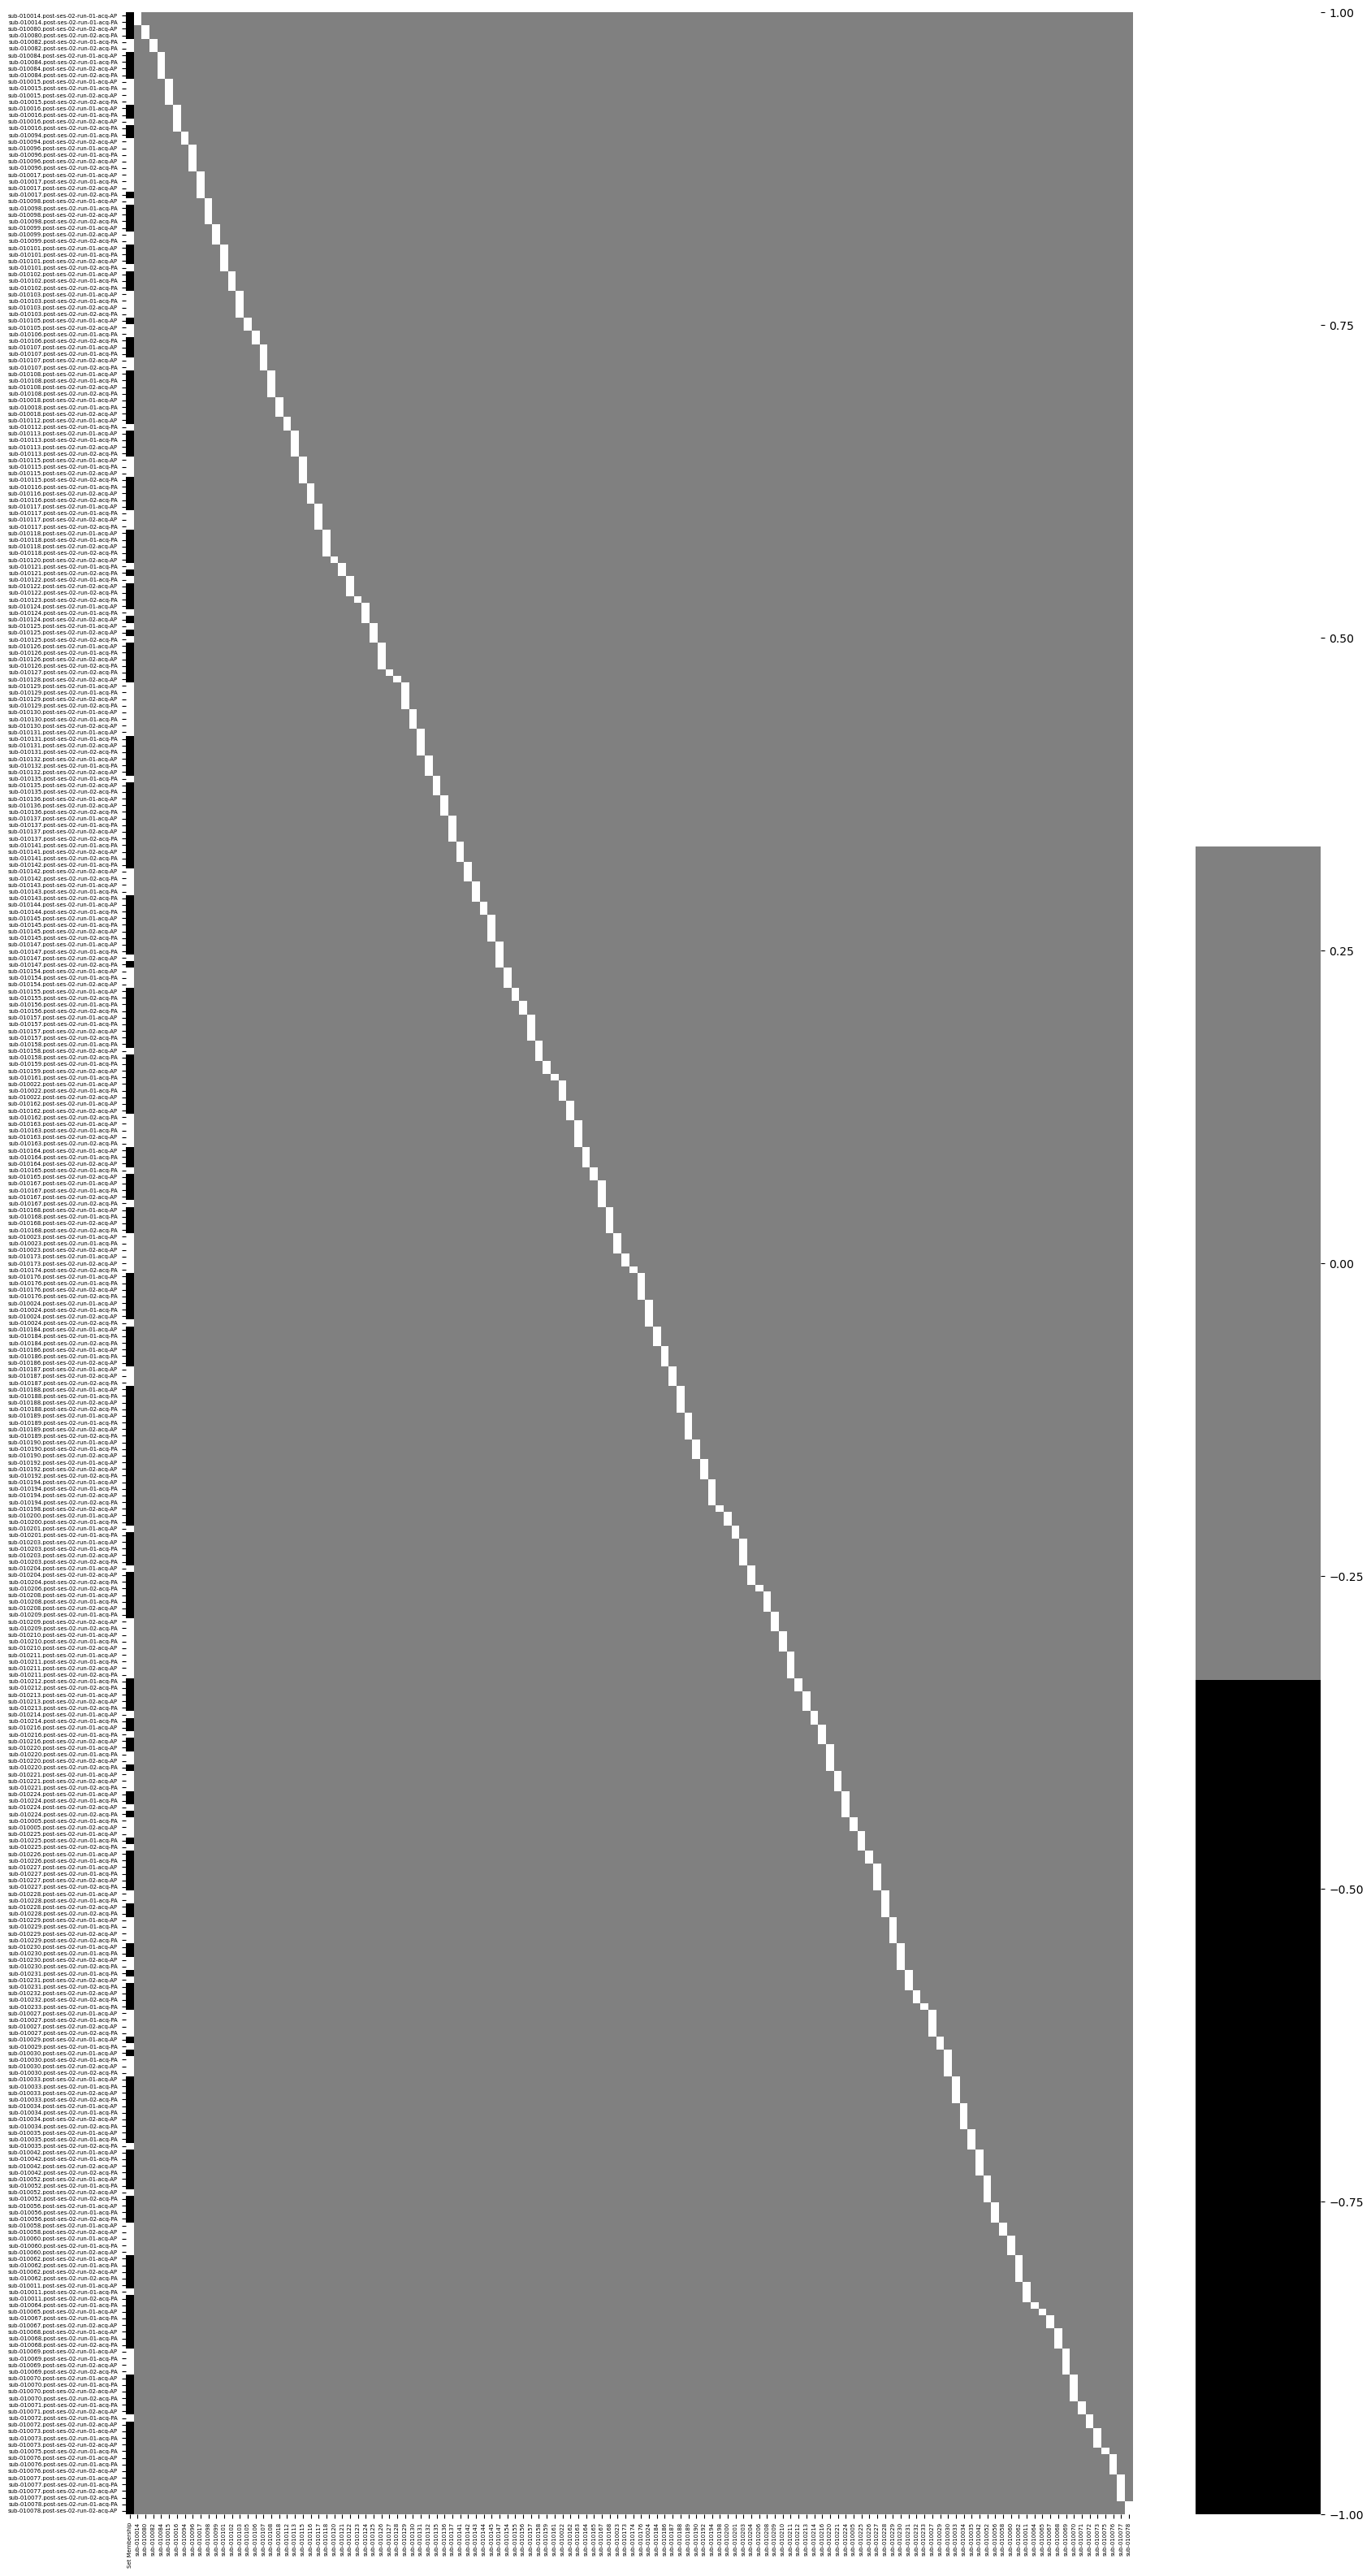

In [19]:
fig, ax          = plt.subplots(1,1,figsize=(20,40))
sns.heatmap(DESING_MATRIX_SBJAWARE, xticklabels=['Set Membership']+FINAL_SBJ_LIST_NOREPS, yticklabels=FINAL_SCAN_LIST, ax=ax, cmap=['black','gray','white'])
ax.tick_params(axis='both', which='major', labelsize=5) 

# 7. Create NBS Contrast Vector Files

In [20]:
CONTRASTS_SBJAWARE={'SetA_gt_SetB':[1]+list(np.zeros(FINAL_N_sbjs).astype(int)),
                    'SetB_gt_SetA':[-1]+list(np.zeros(FINAL_N_sbjs).astype(int))}
for CONTRAST in CONTRASTS_SBJAWARE.keys():
    CONTRAST_PATH = osp.join(RESOURCES_NBS_DIR,ATLAS_NAME,f'NBS_Contrast_{CONTRAST}.txt') 
    np.savetxt(CONTRAST_PATH,np.array(CONTRASTS_SBJAWARE[CONTRAST]).reshape(1,-1),delimiter=' ',fmt='%d')
    print('++ Contrast %s saved to %s' % (CONTRAST, CONTRAST_PATH))
    

++ Contrast SetA_gt_SetB saved to /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/nbs_extra/Schaefer2018_400Parcels_7Networks_AAL2/NBS_Contrast_SetA_gt_SetB.txt
++ Contrast SetB_gt_SetA saved to /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/nbs_extra/Schaefer2018_400Parcels_7Networks_AAL2/NBS_Contrast_SetB_gt_SetA.txt


# 8. Run NBS Analysis in Matlab

Example of how to run for the ```Set A > Set B``` contrast.

1. Open Matlab

2. Load the Path to NBS

```addpath(genpath('/data/SFIMJGC_HCP7T/hcp7t_fv_sleep_extraSW/NBS1.2/'))```

3. Configure NBS appropriately for each of the contrasts

    a. Image-Pos-Others
    
    * ```Design Matrix = /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/nbs/Schaefer2018_400Parcels_7Networks_AAL2/NBS_DesingMatrix_SubjectAware.txt```
    * ```Contrast = /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/nbs/Schaefer2018_400Parcels_7Networks_AAL2/NBS_Contrast_SetA_gt_SetB.txt```
    * ```Statistical Test = T-test```
    * ```Threshold = 3.1``` equivalent to p<0.001
    * ```Connectivity Matrices = /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/nbs/Schaefer2018_400Parcels_7Networks_AAL2/NBS_Data/subject0001.txt```
    * ```Node Coordinates = /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/nbs/Schaefer2018_400Parcels_7Networks_AAL2/Schaefer2018_400Parcels_7Networks_AAL2_NBS_Node_Coordinates.txt```
    * ```Node Labels = /data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/nbs/Schaefer2018_400Parcels_7Networks_AAL2/Schaefer2018_400Parcels_7Networks_AAL2_NBS_Node_Labels.txt```
    * ```Permutations = 5000```
    * ```Significance = 0.05```
    * ```Method = Network-Based Statistics (NBS)```
    * ```Component Size = Extent```
    
    Once the program finish, please save the results as: ```/data/SFIMJGC_Introspec/2023_fc_introspection/code/fc_introspection/resources/nbs/Schaefer2018_400Parcels_7Networks_AAL2/NBS_Results/NBS_SetA_gt_SetB.mat```



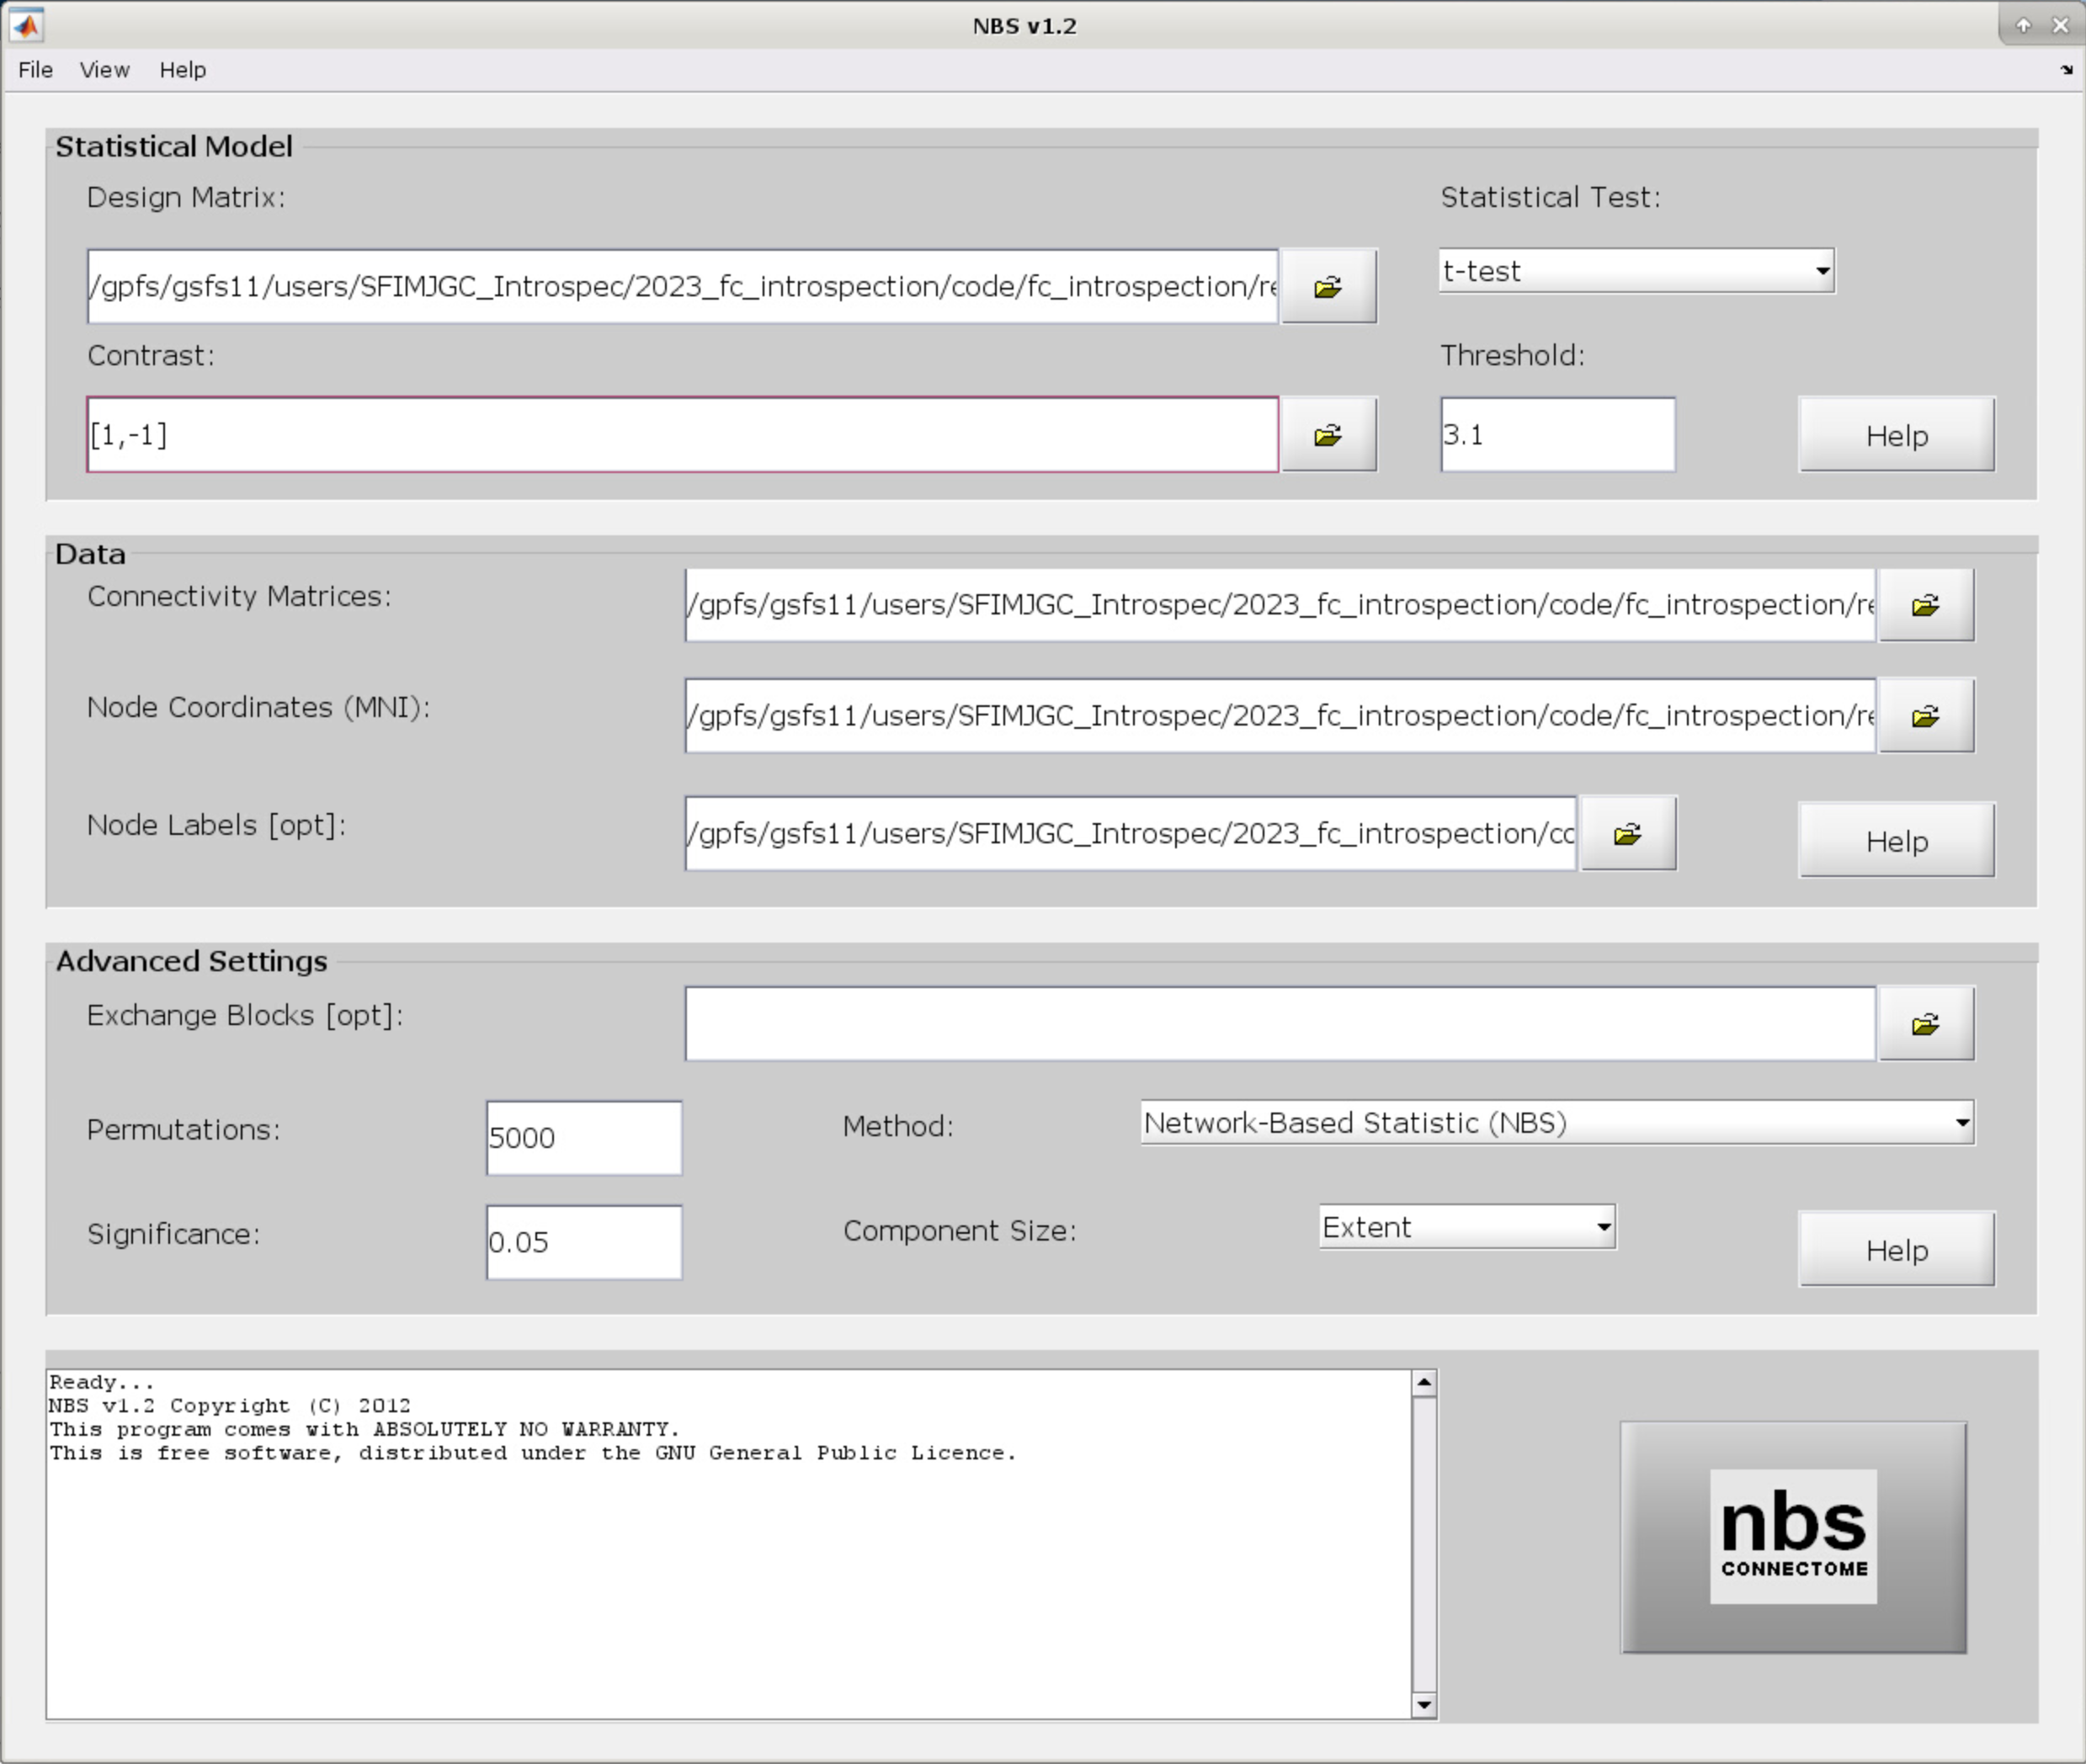

In [20]:
display.Image('./figures/S13_NBS_Configuration.png', width=1200)